<a href="https://colab.research.google.com/github/Joaoplims/sna_roblox_kg/blob/main/Roblox_KG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install requests

## SETUP

In [ ]:
API_KEY = "Bo3UKVecGk6QtPtNkA5tb2DIT+PFVGIxoNpqERPlnIdzQp2RZXlKaGJHY2lPaUpTVXpJMU5pSXNJbXRwWkNJNkluTnBaeTB5TURJeExUQTNMVEV6VkRFNE9qVXhPalE1V2lJc0luUjVjQ0k2SWtwWFZDSjkuZXlKaGRXUWlPaUpTYjJKc2IzaEpiblJsY201aGJDSXNJbWx6Y3lJNklrTnNiM1ZrUVhWMGFHVnVkR2xqWVhScGIyNVRaWEoyYVdObElpd2lZbUZ6WlVGd2FVdGxlU0k2SWtKdk0xVkxWbVZqUjJzMlVYUlFkRTVyUVRWMFlqSkVTVlFyVUVaV1IwbDRiMDV3Y1VWU1VHeHVTV1I2VVhBeVVpSXNJbTkzYm1WeVNXUWlPaUl4TURJME5USXhPRGMwTnlJc0ltVjRjQ0k2TVRjNE1UUTVORGsxTml3aWFXRjBJam94TnpneE5Ea3hNelUyTENKdVltWWlPakUzT0RFME9URXpOVFo5LkRGV0VWVVh2N0dYdk5oWTVwbmFseW5wSjhHRUkwbzBoNEhsVDhobVdybFM2ZzZMWTF1M2gwSEZnRDZNY3VuUDN5XzhORS1GRWFHd3pEeDlYTVBEUWJiemRvMW90UEx1Z2t5WXNOVmZrRUpmV1JDNUwwcUp3VGN4dmdUYU1heldDcTMwRGFtWlBFNXVrTF85OHN6ZU9MWG5XOXBRMGV4cUtZelMzdFNTX0ZuNUIwcm5kb2NNeGltc3c5bTBONmhrQVBtdnBxckppb28zVDNCblkweUpCRWllT2YzSUdoM1JlTWcwYllvdE02b1pIek9GS096OElfZ1A3R0lKUnl4UDBaVWNxU0NxZGNzUHloem5UODkxYUpSRm40WTBZWHR4SEpsLVJNYnpRTDhST2RRZkxjcnlUVHIzdjZXVXgtZDZqVHFDU3ZzLXBHcERna1dONmJQVjc5Zw=="
HEADERS = {
    "x-api-key": API_KEY,
    "Content-Type": "application/json"
}

## Função de Chamada para a API

In [ ]:
import requests

def make_roblox_request(url, method="GET", params=None, data=None):
    """
    Função genérica para realizar chamadas à API do Roblox.
    """
    try:
        response = requests.request(
            method=method,
            url=url,
            headers=HEADERS,
            params=params,
            json=data
        )

        if response.status_code == 200:
            print(f"✅ Sucesso [{method}]: {url}")
            return response.json()
        else:
            print(f"❌ Erro {response.status_code}: {response.text}")
            return None
    except Exception as e:
        print(f"💥 Erro na requisição: {e}")
        return None

# --- Teste usando a nova função ---
user_id = "224"
user_url = f"https://apis.roblox.com/cloud/v2/users/{user_id}"

user_data = make_roblox_request(user_url)

if user_data:
    print(f"Nome: {user_data.get('name')}")
    print(f"Display Name: {user_data.get('displayName')}")

✅ Sucesso [GET]: https://apis.roblox.com/cloud/v2/users/224
Nome: fryanpan
Display Name: fryanpan


## Teste Chama Groups

In [ ]:
import time

# Buscar o Grupo 'Scriptbloxian Studios'
# Pesquisas indicam que é um dos grupos mais populares (https://roblox.fandom.com/pt-br/wiki/Scriptbloxian_Studios)
# Grupo de desenvolvedor de jogos famoso
group_search_url = "https://groups.roblox.com/v1/groups/search/lookup?groupName=Scriptbloxian%20Studios"
group_search_results = make_roblox_request(group_search_url)

if group_search_results and group_search_results.get('data'):
    group_info = group_search_results['data'][0]
    group_id = group_info['id']
    print(f"🎯 Grupo Encontrado: {group_info['name']} (ID: {group_id})")
else:
    print("❌ Grupo não encontrado ou erro na busca.")

✅ Sucesso [GET]: https://groups.roblox.com/v1/groups/search/lookup?groupName=Scriptbloxian%20Studios
🎯 Grupo Encontrado: Scriptbloxian Studios (ID: 4705120)


In [ ]:
# 2. Extrair membros do grupo (Limitando aos primeiros para o teste do grafo)
members_url = f"https://groups.roblox.com/v1/groups/{group_id}/users?sortOrder=Asc&limit=10"
members_data = make_roblox_request(members_url)

user_ids = []
if members_data and members_data.get('data'):
    user_ids = [member['user']['userId'] for member in members_data['data']]
    print(f"👥 Extraídos {len(user_ids)} usuários do grupo.")
    print(f"IDs dos Usuários: {user_ids}")

✅ Sucesso [GET]: https://groups.roblox.com/v1/groups/4705120/users?sortOrder=Asc&limit=10
👥 Extraídos 10 usuários do grupo.
IDs dos Usuários: [947838656, 1027961385, 357829182, 244267273, 740396998, 731822913, 871184693, 262953699, 940534557, 970378427]


In [ ]:
# 3. Extrair outros grupos que esses usuários participam
knowledge_graph_edges = []

for uid in user_ids[:5]:  # Testando com os 5 primeiros para evitar rate limiting
    user_groups_url = f"https://groups.roblox.com/v1/users/{uid}/groups/roles"
    ug_data = make_roblox_request(user_groups_url)

    if ug_data and ug_data.get('data'):
        for entry in ug_data['data']:
            group_node = entry['group']
            knowledge_graph_edges.append({
                'from_user': uid,
                'to_group_id': group_node['id'],
                'to_group_name': group_node['name']
            })
    time.sleep(0.5) # Pequeno delay preventivo

print(f"🕸️ Mapeadas {len(knowledge_graph_edges)} conexões para o Knowledge Graph.")
if knowledge_graph_edges:
    display(knowledge_graph_edges[:5])

✅ Sucesso [GET]: https://groups.roblox.com/v1/users/947838656/groups/roles
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/1027961385/groups/roles
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/357829182/groups/roles
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/244267273/groups/roles
✅ Sucesso [GET]: https://groups.roblox.com/v1/users/740396998/groups/roles
🕸️ Mapeadas 80 conexões para o Knowledge Graph.


[{'from_user': 947838656,
  'to_group_id': 257737430,
  'to_group_name': 'Mischief Mechanics'},
 {'from_user': 947838656,
  'to_group_id': 10975897,
  'to_group_name': 'XP Games.'},
 {'from_user': 947838656,
  'to_group_id': 32794027,
  'to_group_name': 'Titan Trainers'},
 {'from_user': 947838656,
  'to_group_id': 32073904,
  'to_group_name': 'Hero Rivals Arena'},
 {'from_user': 947838656,
  'to_group_id': 16345189,
  'to_group_name': 'Super Slide'}]

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47204 (\N{HANGUL SYLLABLE ROL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50892 (\N{HANGUL SYLLABLE WEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

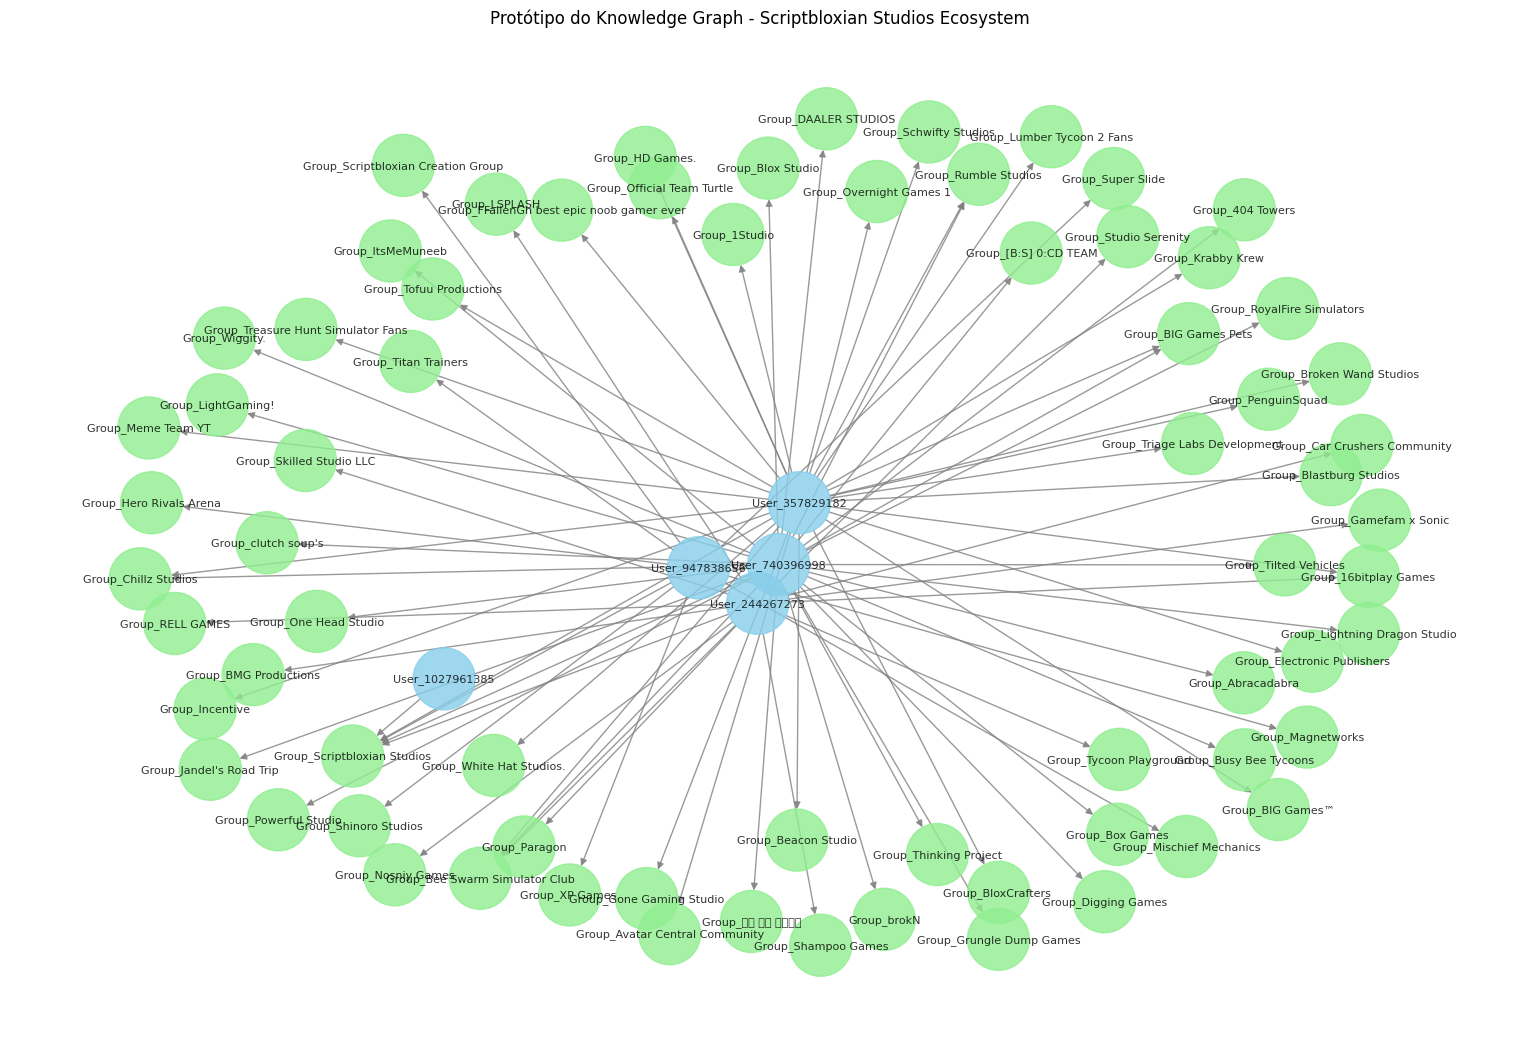

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Criando o objeto do grafo
G = nx.DiGraph()

# Adicionando as conexões (edges) ao grafo
for edge in knowledge_graph_edges:
    user_node = f"User_{edge['from_user']}"
    group_node = f"Group_{edge['to_group_name']}"

    G.add_node(user_node, type='user')
    G.add_node(group_node, type='group')
    G.add_edge(user_node, group_node)

# Configurações de visualização
plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.15, iterations=20)

# Cores diferentes para usuários e grupos
node_colors = ['skyblue' if G.nodes[node].get('type') == 'user' else 'lightgreen' for node in G.nodes()]

nx.draw(G, pos, with_labels=True,
        node_color=node_colors,
        node_size=2000,
        font_size=8,
        arrows=True,
        edge_color='gray',
        alpha=0.8)

plt.title("Protótipo do Knowledge Graph - Scriptbloxian Studios Ecosystem")
plt.show()